# Klasifikacija melanoma

Ovaj notebook sadrzi celokupan pipeline za klasifikaciju melanoma:

0. Setup
1. Dataset
2. Preprocessing
3. CNN treniranje
4. EfficientNet treniranje
5. DenseNet121 treniranje
6. ResNet50 treniranje
7. Evaluacija
8. Analiza gresaka
9. Fairness
10. Rezime


Svaki model se trenira nezavisno i rezultati se cuvaju na Drive.

---
## 0. Setup okruzenja

Proveravamo GPU, instaliramo zavisnosti i povezujemo Google Drive.

### 0.1 Provera GPU-a

Pre pokretanja obavezno ukljuciti GPU: `Runtime -> Change runtime type -> GPU (T4)`

In [ ]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA dostupna: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU memorija: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("UPOZORENJE: GPU NIJE DOSTUPAN!")
    print("Idite na Runtime -> Change runtime type -> GPU")

PyTorch: 2.10.0+cu128
CUDA dostupna: True
GPU: Tesla T4
GPU memorija: 15.6 GB


### 0.2 Instalacija zavisnosti

In [ ]:
!pip install -q timm albumentations mahotas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 40.6 MB/s eta 0:00:00


### 0.3 Google Drive + src/ moduli

Povezujemo Google Drive gde se nalaze nasi `src/` Python moduli i gde cemo sacuvati rezultate.

In [ ]:
import os, sys, shutil
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Kopiraj src/ sa Drive-a na lokalni disk (brze citanje)
REPO_DIR = '/content/neuronske-2'
SRC_DRIVE = '/content/drive/MyDrive/neuronske-2/src'
SRC_LOCAL = f'{REPO_DIR}/src'

if not os.path.exists(SRC_LOCAL):
    os.makedirs(REPO_DIR, exist_ok=True)
    shutil.copytree(SRC_DRIVE, SRC_LOCAL)
    print(f"src/ kopiran sa Drive-a na {SRC_LOCAL}")
else:
    print(f"src/ vec postoji na {SRC_LOCAL}")

sys.path.insert(0, REPO_DIR)

# Kreiraj folder za rezultate na Drive-u
RESULTS_DIR = '/content/drive/MyDrive/melanoma_results'
MODELS_DIR = f'{RESULTS_DIR}/models'
os.makedirs(MODELS_DIR, exist_ok=True)

# Verifikacija
print(f"\nsrc/ moduli dostupni: {os.path.exists(f'{SRC_LOCAL}/config.py')}")
print(f"Rezultati ce se cuvati u: {RESULTS_DIR}")

Mounted at /content/drive
src/ vec postoji na /content/neuronske-2/src

src/ moduli dostupni: True
Rezultati ce se cuvati u: /content/drive/MyDrive/melanoma_results


---
## 1. Preuzimanje dataseta sa Kaggle-a

Dataset: ISIC Challenge 2020 (~23GB, ~33,000 dermoskopskih slika).

Potreban nam je Kaggle API kljuc (`kaggle.json`).
Kljuc se pre prvog pokretanja kreira na `https://www.kaggle.com/settings -> API -> Create New Token`.

### 1.1 Kaggle API Setup

In [ ]:
from google.colab import files

if not os.path.exists(os.path.expanduser('~/.kaggle/kaggle.json')):
    print("Upload-ujte vas kaggle.json fajl:")
    uploaded = files.upload()
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("Kaggle API konfigurisan!")
else:
    print("Kaggle API vec konfigurisan.")

Upload-ujte vas kaggle.json fajl:


Saving kaggle.json to kaggle.json
Kaggle API konfigurisan!


### 1.2 Preuzimanje i raspakivanje

U ovom koraku se vrši preuzimanje i raspakivanje ISIC 2020 dataset-a sa Kaggle platforme. Ovaj korak se izvršava svaki put kada pokrećemo notebook jer `/content/data` nije trajno skladište podataka i briše se nakon završetka sesije.

In [ ]:
DATA_DIR = '/content/data'

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    print("Preuzimanje dataseta sa Kaggle-a (~23GB)...")
    !kaggle datasets download -d sumaiyabinteshahid/isic-challenge-dataset-2020 -p {DATA_DIR}
    print("\nRaspakivanje...")
    !unzip -q {DATA_DIR}/*.zip -d {DATA_DIR}
    !rm -f {DATA_DIR}/*.zip
    print("Gotovo!")
else:
    print(f"Dataset vec postoji na {DATA_DIR}")

Preuzimanje dataseta sa Kaggle-a (~23GB)...
Dataset URL: https://www.kaggle.com/datasets/sumaiyabinteshahid/isic-challenge-dataset-2020
License(s): CC0-1.0
100% 29.8G/29.8G [05:13<00:00, 102MB/s]


Raspakivanje...
Gotovo!


### 1.3 Pronalaženje strukture dataseta

U ovom koraku učitavamo podatke iz CSV datoteke i pronalazimo slike koje će nam biti neophodne za treniranje.

In [ ]:
import glob
import pandas as pd

# Pronadji CSV i slike
csv_files = glob.glob(f"{DATA_DIR}/**/ISIC_2020_Train_Metadata.csv", recursive=True)
jpg_files = glob.glob(f"{DATA_DIR}/**/*.jpg", recursive=True)

TRAIN_CSV = csv_files[0] if csv_files else None
TRAIN_DIR = os.path.dirname(jpg_files[0]) if jpg_files else None

print(f"TRAIN_CSV = {TRAIN_CSV}")
print(f"TRAIN_DIR = {TRAIN_DIR}")
print(f"Ukupno JPG slika: {len(jpg_files)}")

# Statistika dataseta
df_info = pd.read_csv(TRAIN_CSV)
print(f"\nBroj redova u CSV: {len(df_info)}")
print(f"Kolone: {list(df_info.columns)}")
print(f"\nRaspodela klasa:")
print(f"  Benign:    {(df_info['target'] == 0).sum()} ({(df_info['target'] == 0).mean()*100:.1f}%)")
print(f"  Malignant: {(df_info['target'] == 1).sum()} ({(df_info['target'] == 1).mean()*100:.1f}%)")
print(f"\nBroj pacijenata: {df_info['patient_id'].nunique()}")

TRAIN_CSV = /content/data/ISIC_2020_Dataset/ISIC_2020_Train_Metadata.csv
TRAIN_DIR = /content/data/ISIC_2020_Dataset/train
Ukupno JPG slika: 44108

Broj redova u CSV: 33126
Kolone: ['image_name', 'patient_id', 'lesion_id', 'sex', 'age_approx', 'anatom_site_general_challenge', 'diagnosis', 'benign_malignant', 'target']

Raspodela klasa:
  Benign:    32542 (98.2%)
  Malignant: 584 (1.8%)

Broj pacijenata: 2056


Dataset je jako nebalansiran (~98% benignih, ~2% malignih). Koristićemo `pos_weight` u loss funkciji i stratifikovanu cross-validaciju.

### 1.4 Primer slike iz dataseta

Ovde vršimo prikaz primera slike iz dataset-a zajedno sa vrednošću target varijable za navedenu sliku.

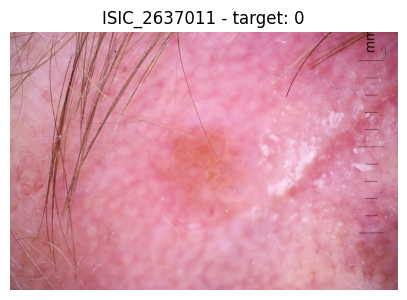

Dimenzije slike: (4000, 6000, 3)


In [ ]:
import cv2
import matplotlib.pyplot as plt

sample = df_info.iloc[0]
sample_path = os.path.join(TRAIN_DIR, f"{sample['image_name']}.jpg")
img = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"{sample['image_name']} - target: {sample['target']}")
plt.axis('off')
plt.show()
print(f"Dimenzije slike: {img.shape}")

---
## 2. Konfiguracija i preprocessing

Postavljamo konfiguraciju i prikazujemo korake preprocesiranja.

### 2.1 Konfiguracija

Ova konfiguracija je napravljena za rad sa Google Colab-om. Ukoliko se treniranje vrši na lokalnom računaru, moguće je korigovati konfiguraciju u skladu sa tehničkim mogućnostima računara.

In [ ]:
from src.config import Config

cfg = Config.colab()
cfg.train_csv = TRAIN_CSV
cfg.train_dir = TRAIN_DIR
cfg.model_save_dir = MODELS_DIR

print(f"Device: {cfg.get_device()}")
print(f"Epochs: {cfg.epochs}")
print(f"Folds: {cfg.num_folds}")
print(f"Batch size: {cfg.batch_size}")
print(f"Train CSV: {cfg.train_csv}")
print(f"Train DIR: {cfg.train_dir}")
print(f"Models DIR: {cfg.model_save_dir}")

Device: cuda
Epochs: 20
Folds: 5
Batch size: 32
Train CSV: /content/data/ISIC_2020_Dataset/ISIC_2020_Train_Metadata.csv
Train DIR: /content/data/ISIC_2020_Dataset/train
Models DIR: /content/drive/MyDrive/melanoma_results/models


### 2.2 Uklanjanje dlaka (Hair Removal)

Dermoskopske slike cesto sadrže dlake koje mogu omesti klasifikaciju. Koristimo Black-Hat morfološku transformaciju za detekciju dlaka, a zatim Telea *inpainting* algoritam za njihovo uklanjanje.

Postupak:
1. Konvertovanje u grayscale
2. Black-Hat transformacija sa strukturnim elementom (15x15)
3. Binarizacija maske (prag = 10)
4. Inpainting koristeci Telea algoritam

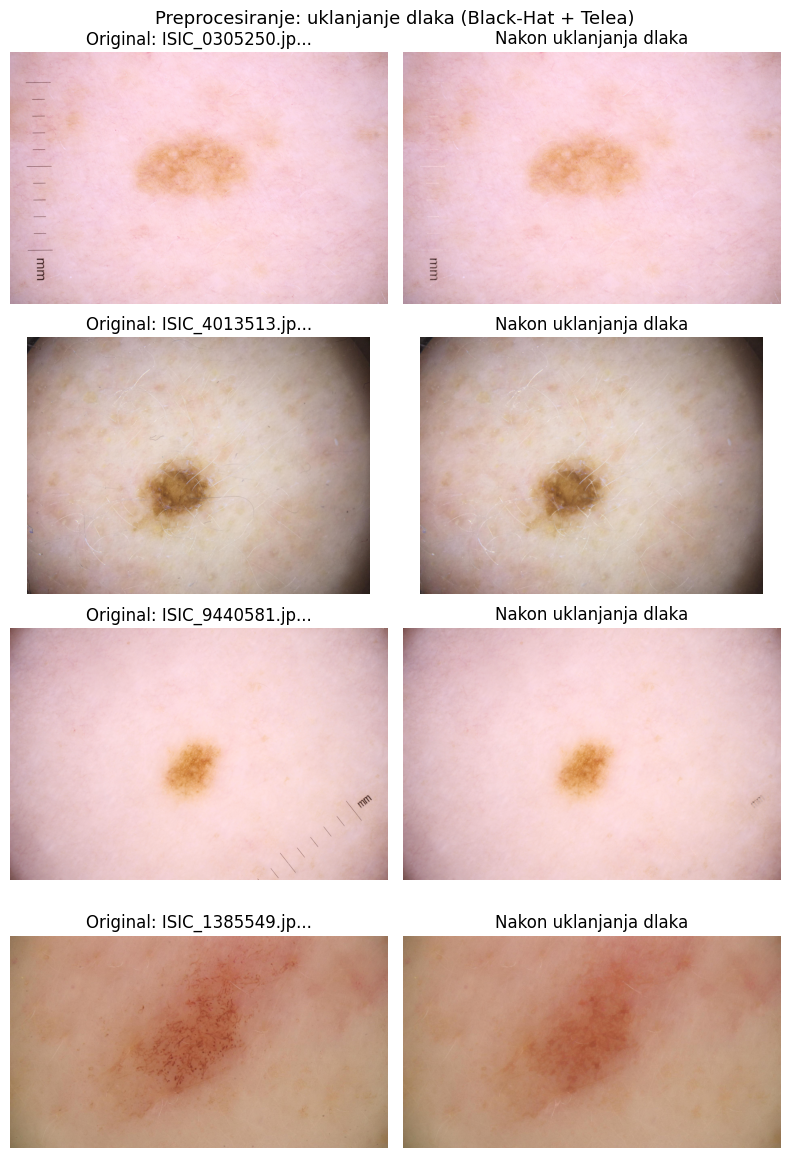

In [ ]:
import numpy as np
from src.preprocessing import remove_hairs
from src.visualization import plot_preprocessing_examples

fig = plot_preprocessing_examples(cfg.train_dir, n=4)
plt.show()

Black-Hat transformacija uspešno detektuje tamne linearne strukture (dlake) na svetloj koži, a Telea inpainting ih zamenjuje okolnim pikselima.

### 2.3 Ekstrakcija Hu momenata

Hu momenti su 7 invarijantnih momenata koji opisuju oblik objekta na slici. Invarijantni su na translaciju, skaliranje i rotaciju. Koristimo prva 4 Hu momenta sa log-transformacijom za numeričku stabilnost.

In [ ]:
from src.features import calculate_hu_moments

img_files = [f for f in os.listdir(cfg.train_dir) if f.endswith('.jpg')][:8]
hu_data = []

for fname in img_files:
    img = cv2.imread(os.path.join(cfg.train_dir, fname))
    cleaned = remove_hairs(img)
    hu = calculate_hu_moments(cleaned, n_moments=4)
    hu_data.append({
        'image': fname[:20],
        'Hu1': f'{hu[0]:.4f}',
        'Hu2': f'{hu[1]:.4f}',
        'Hu3': f'{hu[2]:.4f}',
        'Hu4': f'{hu[3]:.4f}',
    })

hu_df = pd.DataFrame(hu_data)
print("Hu momenti za primere slika (log-transformisani):")
hu_df

Hu momenti za primere slika (log-transformisani):


,image,Hu1,Hu2,Hu3,Hu4
0,ISIC_1461068.jpg,3.1701,7.8974,9.9880,9.9992
1,ISIC_7466101.jpg,3.0775,7.2735,9.9473,9.9903
2,ISIC_2993517.jpg,3.1548,7.5679,9.9926,9.9994
3,ISIC_1092935.jpg,3.1341,7.7012,9.9992,9.9981
4,ISIC_7892118.jpg,3.0492,6.6604,9.9987,9.9985
5,ISIC_5110209.jpg,3.1421,7.5513,9.9992,9.9989
6,ISIC_3741760.jpg,3.0101,6.5714,9.9944,9.9958
7,ISIC_0154870.jpg,3.1501,7.6657,9.9916,9.9995


Hu momenti se razlikuju između slika, što znači da nose informaciju o obliku lezije. Koriste se kao dodatni ulaz u model (*late fusion*).

### 2.4 Enkodiranje metapodataka

Pored vizuelnih obelezja, koristimo i metapodatke pacijenata:
- Pol (sex) - one-hot enkodiranje
- Anatomska lokacija (anatom_site_general_challenge) - one-hot enkodiranje
- Starost (age_approx) - min-max normalizacija na [0, 1]

In [ ]:
from src.features import encode_metadata

df_demo = pd.read_csv(cfg.train_csv)
df_encoded, metadata_cols, metadata_dim = encode_metadata(df_demo)

print(f"Metadata kolone ({metadata_dim}): {metadata_cols}")
print(f"\nPrimer enkodiranih metapodataka (prvih 5 redova):")
df_encoded[metadata_cols].head()

Metadata kolone (11): ['sex_female', 'sex_male', 'sex_unknown', 'site_head/neck', 'site_lower extremity', 'site_oral/genital', 'site_palms/soles', 'site_torso', 'site_unknown', 'site_upper extremity', 'age_norm']

Primer enkodiranih metapodataka (prvih 5 redova):


,sex_female,sex_male,sex_unknown,site_head/neck,site_lower extremity,site_oral/genital,site_palms/soles,site_torso,site_unknown,site_upper extremity,age_norm
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500000
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.500000
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.555556
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500000
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.611111


Nakon ovog koraka, svaki pacijent ima numerički vektor metapodataka. Ovaj vektor se spaja sa Hu momentima (4 vrednosti) u drugoj grani modela (*late fusion*).

### 2.5 Augmentacija podataka

Zbog izrazitog disbalansa klasa koristimo *on-the-fly* augmentaciju tokom treniranja:
- Horizontalni i vertikalni flip, rotacija za 90 stepeni
- Shift-Scale-Rotate, ColorJitter
- Normalizacija (ImageNet mean/std)

Augmentacija se primenjuje samo na trening skup. Ovaj pristup ne može da izazove curenje podataka izmedju foldova.

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


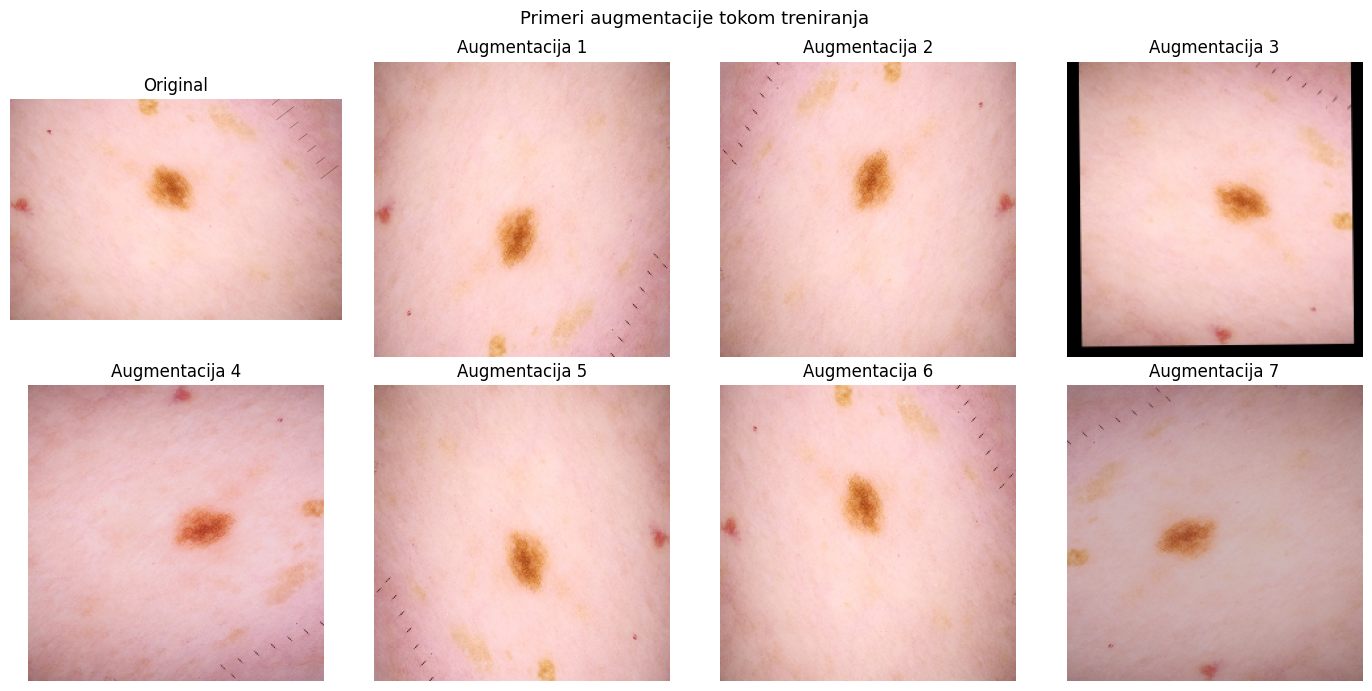

In [ ]:
from src.augmentation import get_train_transforms

train_t = get_train_transforms(cfg.image_size)

sample_img = cv2.imread(os.path.join(cfg.train_dir, img_files[0]))
sample_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes[0, 0].imshow(sample_rgb)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

for i in range(1, 8):
    row, col = divmod(i, 4)
    augmented = train_t(image=sample_rgb)['image']
    img_show = augmented.permute(1, 2, 0).numpy()
    img_show = img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_show = np.clip(img_show, 0, 1)
    axes[row, col].imshow(img_show)
    axes[row, col].set_title(f'Augmentacija {i}')
    axes[row, col].axis('off')

fig.suptitle('Primeri augmentacije tokom treniranja', fontsize=13)
plt.tight_layout()
plt.show()

Augmentacija generiše različite varijacije iste slike, što smanjuje *overfitting*, posebno za malobrojnu malignu klasu.

### 2.6 *Offline* preprocesiranje svih slika

Ovo je ključni korak za performanse i izvršava se samo jednom. Umesto da za svaku sliku radimo resize + hair removal + Hu momente tokom treniranja (što se ponavlja svaku epohu), uradićemo to jednom za sve slike i sačuvati rezultate.

Preprocesiramo za oba modela unapred:
- 128x128 za Custom CNN
- 224x224 za EfficientNet

Ovaj korak će potrajati malo duže, ali posle toga treniranje je drastično brže jer DataLoader samo čita gotove numpy fajlove.

In [ ]:
from src.preprocessing_cache import preprocess_and_cache
from src.data_utils import load_and_prepare_data

# Ucitaj podatke (potrebno za listu slika)
df = load_and_prepare_data(cfg)
print(f"Ukupno slika za preprocesiranje: {len(df)}")

# Preprocesiraj za CNN (128x128)
# CNN_CACHE = "/content/preprocessed_128"
# print("[1/2] Preprocesiranje za CNN (128x128)...")
# preprocess_and_cache(df, cfg.train_dir, CNN_CACHE, image_size=128,
#                      apply_hair_removal=cfg.apply_hair_removal)

# Preprocesiraj za EfficientNet (224x224)
EFFNET_CACHE = "/content/preprocessed_224"
print("[2/2] Preprocesiranje za EfficientNet (224x224)...")
preprocess_and_cache(df, cfg.train_dir, EFFNET_CACHE, image_size=224,
                     apply_hair_removal=cfg.apply_hair_removal)

print("Preprocesiranje zavrseno! Slike su spremne za treniranje.")

Ukupno slika za preprocesiranje: 33126
[2/2] Preprocesiranje za EfficientNet (224x224)...


Preprocessing 224x224: 100%|██████████| 33126/33126 [24:30<00:00, 22.53it/s]

Resumed: 17289 images already cached, processed 15837 new.
Done! 33126 images cached in /content/preprocessed_224
Preprocesiranje zavrseno! Slike su spremne za treniranje.


Sve slike su preprocesirane i sačuvane kao numpy fajlovi. Tokom treniranja, DataLoader samo cita gotove fajlove umesto da ponovo radi *resize, hair removal* i ekstrakciju Hu momenata za svaku sliku i svaku epohu. Ovo ubrzava treniranje od 10 do 100 puta.

---
## 3. Treniranje Custom CNN modela

Naš Custom CNN model se sastoji od:
- 3 konvoluciona sloja (32->64->128 filtera) sa BatchNorm i ReLU
- AdaptiveAvgPool -> vektor od 128 dimenzija
- *Late fusion*: spajanje vizuelnih obelžja (128-dim) sa metapodacima (Hu momenti + encoded metadata)
- Klasifikator: FC(128+feat_dim -> 64) -> FC(64 -> 1)

Treniramo sa:
- *StratifiedGroupKFold* - podela po pacijentima (sprečava curenje podataka)
- *BCEWithLogitsLoss* sa pos_weight za balansiranje klasa
- *Early stopping* na osnovu validacionog AUC-ROC

In [ ]:
from src.data_utils import load_and_prepare_data
from src.training import run_cross_validation
from src.visualization import plot_all_folds_losses, plot_roc_curve, plot_fold_comparison

### 3.1 Konfiguracija CNN-a

In [ ]:
cfg.model_type = 'cnn'
cfg.image_size = 128
cfg.cache_dir = CNN_CACHE  # Koristi preprocesirane slike

print(f"Model: {cfg.model_type}")
print(f"Image size: {cfg.image_size}x{cfg.image_size}")
print(f"Epochs: {cfg.epochs}, Folds: {cfg.num_folds}")
print(f"Batch size: {cfg.batch_size}")
print(f"Device: {cfg.get_device()}")

### 3.2 Učitavanje podataka

In [ ]:
df = load_and_prepare_data(cfg)

print(f"Ukupno slika: {len(df)}")
print(f"Raspodela klasa:")
print(f"  Benign:    {(df['target'] == 0).sum()} ({(df['target'] == 0).mean()*100:.1f}%)")
print(f"  Malignant: {(df['target'] == 1).sum()} ({(df['target'] == 1).mean()*100:.1f}%)")
print(f"Broj pacijenata: {df['patient_id'].nunique()}")
print(f"Feature dim: {cfg.feature_dim}")

### 3.3 Treniranje sa k-fold cross-validacijom


In [ ]:
cnn_results = run_cross_validation(df, cfg)

### 3.4 Vizualizacija rezultata CNN-a

In [ ]:
# Krive gubitka po foldovima
fig = plot_all_folds_losses(cnn_results['per_fold_results'])
plt.show()

*Train loss* opada kroz epohe. Ako val loss pocne da raste dok *train loss* opada, to ukazuje na *overfitting*, pa *early stopping* zaustavlja treniranje pre toga.

In [ ]:
# ROC kriva
fig = plot_roc_curve(
    cnn_results['oof_labels'],
    cnn_results['oof_probs'],
    fold_results=cnn_results['per_fold_results'],
    label='Custom CNN'
)
plt.show()

In [ ]:
# Poredjenje AUC po foldovima
fig = plot_fold_comparison(cnn_results['per_fold_results'])
plt.show()

print(f"\nCNN Mean AUC: {cnn_results['mean_auc']:.4f} +/- {cnn_results['std_auc']:.4f}")

### 3.5 Čuvanje CNN rezultata na Drive

Ovo radimo jer smo menjali naloge kako bismo zaobišli limite Google Colab-a, pa čuvamo rezultate u fajlove kako bismo kasnije mogli da ih pročitamo i iskoristimo za analizu.

In [ ]:
import pickle

cnn_save_path = os.path.join(RESULTS_DIR, 'cnn_results.pkl')
with open(cnn_save_path, 'wb') as f:
    pickle.dump({
        'oof_labels': cnn_results['oof_labels'],
        'oof_probs': cnn_results['oof_probs'],
        'oof_df': cnn_results['oof_df'],
        'mean_auc': cnn_results['mean_auc'],
        'std_auc': cnn_results['std_auc'],
        'per_fold_aucs': [r['best_val_auc'] for r in cnn_results['per_fold_results']],
    }, f)

print(f"CNN rezultati sacuvani u: {cnn_save_path}")

Custom CNN model je treniran. Rezultati su sačuvani na Google Drive-u za slučaj da se sesija prekine pre EfficientNet treniranja.

---
## 4. Treniranje EfficientNet B0 modela

EfficientNet B0 je pretreniran model na ImageNet datasetu (*transfer learning*).

Arhitektura:
- EfficientNet B0 backbone (pretreniran na ImageNet) -> 1280-dim vektor
- Late fusion: spajanje sa metapodacima (Hu momenti + encoded metadata)
- Klasifikator: FC(1280+feat_dim -> 256) -> FC(256 -> 1)

Očekujemo bolje rezultate od Custom CNN-a jer koristi transferovano znanje sa milionima slika.

### 4.1 Konfiguracija EfficientNet-a

In [ ]:
cfg.model_type = 'efficientnet'
cfg.image_size = 224
cfg.cache_dir = EFFNET_CACHE  # Koristi preprocesirane slike

print(f"Model: {cfg.model_type}")
print(f"Image size: {cfg.image_size}x{cfg.image_size}")
print(f"Epochs: {cfg.epochs}, Folds: {cfg.num_folds}")
print(f"Batch size: {cfg.batch_size}")
print(f"Device: {cfg.get_device()}")

### 4.2 Treniranje sa k-fold cross-validacijom

Treniranje EfficientNet-a traje nešto duže jer se koriste slike veće rezolucije (224x224 u odnosu na 128x128 kod Custom CNN-a).

In [ ]:
effnet_results = run_cross_validation(df, cfg)

### 4.3 Vizualizacija rezultata EfficientNet-a

In [ ]:
fig = plot_all_folds_losses(effnet_results['per_fold_results'])
plt.show()

In [ ]:
fig = plot_roc_curve(
    effnet_results['oof_labels'],
    effnet_results['oof_probs'],
    fold_results=effnet_results['per_fold_results'],
    label='EfficientNet B0'
)
plt.show()

In [ ]:
fig = plot_fold_comparison(effnet_results['per_fold_results'])
plt.show()

print(f"\nEfficientNet Mean AUC: {effnet_results['mean_auc']:.4f} +/- {effnet_results['std_auc']:.4f}")

### 4.4 Čuvanje EfficientNet rezultata na Drive

In [ ]:
effnet_save_path = os.path.join(RESULTS_DIR, 'effnet_results.pkl')
with open(effnet_save_path, 'wb') as f:
    pickle.dump({
        'oof_labels': effnet_results['oof_labels'],
        'oof_probs': effnet_results['oof_probs'],
        'oof_df': effnet_results['oof_df'],
        'mean_auc': effnet_results['mean_auc'],
        'std_auc': effnet_results['std_auc'],
        'per_fold_aucs': [r['best_val_auc'] for r in effnet_results['per_fold_results']],
    }, f)

print(f"EfficientNet rezultati sacuvani u: {effnet_save_path}")

EfficientNet model je treniran. Oba modela su sačuvana na Drive-u.

---
## 5. Treniranje DenseNet-121 modela

DenseNet-121 (*Dense Convolutional Network*) koristi guste veze (eng. *dense connections*) — svaki sloj prima feature mape od SVIH prethodnih slojeva. Ovo omogućava:
- Bolji protok gradijenata tokom treniranja
- Efikasnije koriscenje obeležja (*feature reuse*)
- Manje parametara nego ResNet za slične performanse

Koristimo DenseNet-121 pretreniran na ImageNet-u, sa kasnom fuzijom metapodataka (isto kao EfficientNet).

Izlaz backbone-a: 1024-dim vektor (manji od EfficientNet-ovih 1280).

### 5.1 Konfiguracija DenseNet-121

In [ ]:
cfg.model_type = 'densenet'
cfg.image_size = 224
cfg.cache_dir = EFFNET_CACHE  # Isti cache kao EfficientNet (224x224)

print(f"Model: {cfg.model_type}")
print(f"Image size: {cfg.image_size}x{cfg.image_size}")
print(f"Epochs: {cfg.epochs}, Folds: {cfg.num_folds}")
print(f"Batch size: {cfg.batch_size}")
print(f"Device: {cfg.get_device()}")

### 5.2 Treniranje sa k-fold cross-validacijom

DenseNet-121 koristi 224x224 slike (isti cache kao EfficientNet).

In [ ]:
densenet_results = run_cross_validation(df, cfg)

### 5.3 Vizualizacija rezultata DenseNet-121

In [ ]:
fig = plot_all_folds_losses(densenet_results['per_fold_results'])
plt.show()

In [ ]:
fig = plot_roc_curve(
    densenet_results['oof_labels'],
    densenet_results['oof_probs'],
    fold_results=densenet_results['per_fold_results'],
    title='DenseNet-121 ROC Curve'
)
plt.show()

In [ ]:
fig = plot_fold_comparison(densenet_results['per_fold_results'])
plt.show()

print(f"\nDenseNet-121 Mean AUC: {densenet_results['mean_auc']:.4f} +/- {densenet_results['std_auc']:.4f}")

### 5.4 Čuvanje DenseNet-121 rezultata na Drive

In [ ]:
densenet_save_path = os.path.join(RESULTS_DIR, 'densenet_results.pkl')
with open(densenet_save_path, 'wb') as f:
    pickle.dump(densenet_results, f)

print(f"DenseNet-121 rezultati sacuvani u: {densenet_save_path}")

DenseNet-121 model je treniran. *Dense connections* omogućavaju efikasno korišćenje obeležja iz svih slojeva mreže.

---
## 6. Treniranje ResNet-50 modela

ResNet-50 (*Residual Network*) uvodi rezidualne veze (eng. *skip connections*) koje omogućavaju treniranje veoma dubokih mreža (50+ slojeva) bez problema nestajućih gradijenata.

Ključna inovacija: umesto da uči `H(x)`, mreza uci rezidual `F(x) = H(x) - x`, sto je lakše optimizovati.

Koristimo ResNet-50 pretreniran na ImageNet-u, sa kasnom fuzijom metapodataka.

Izlaz backbone-a: 2048-dim vektor (najveći od sva 4 modela).

### 6.1 Konfiguracija ResNet-50

In [ ]:
cfg.model_type = 'resnet50'
cfg.image_size = 224
cfg.cache_dir = EFFNET_CACHE  # Isti cache kao EfficientNet i DenseNet (224x224)

print(f"Model: {cfg.model_type}")
print(f"Image size: {cfg.image_size}x{cfg.image_size}")
print(f"Epochs: {cfg.epochs}, Folds: {cfg.num_folds}")
print(f"Batch size: {cfg.batch_size}")
print(f"Device: {cfg.get_device()}")

Model: resnet50
Image size: 224x224
Epochs: 20, Folds: 5
Batch size: 32
Device: cuda


### 6.2 Treniranje sa k-fold cross-validacijom

ResNet-50 koristi 224x224 slike (isto kao kod EfficientNet-a i DenseNet-a).

In [ ]:
resnet_results = run_cross_validation(df, cfg)


Target distribution: {0: 32542, 1: 584}
Running 5-fold CV with resnet50 model


--- Fold 1/5 ---
  Train: 26466 samples (462 malignant)
  Val:   6660 samples (122 malignant)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Train:   0%|          | 0/828 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Fold 0 | Epoch 1/20 | Train Loss: 1.1513 | Val Loss: 1.0597 | Val AUC: 0.8373 | Val Acc: 0.4916


...

  Fold 4 | Epoch 17/20 | Train Loss: 0.6746 | Val Loss: 1.2046 | Val AUC: 0.8687 | Val Acc: 0.8405


Train:   0%|          | 0/834 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Fold 4 | Epoch 18/20 | Train Loss: 0.6389 | Val Loss: 1.2936 | Val AUC: 0.8671 | Val Acc: 0.8473


Train:   0%|          | 0/834 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
                                                      

  Fold 4 | Epoch 19/20 | Train Loss: 0.5992 | Val Loss: 1.3337 | Val AUC: 0.8668 | Val Acc: 0.8498
  Early stopping at epoch 19

Cross-Validation Results (resnet50)
Mean AUC: 0.8892 +/- 0.0249
Per-fold AUCs: ['0.9058', '0.9032', '0.9145', '0.8466', '0.8761']


### 6.3 Vizualizacija rezultata ResNet-50

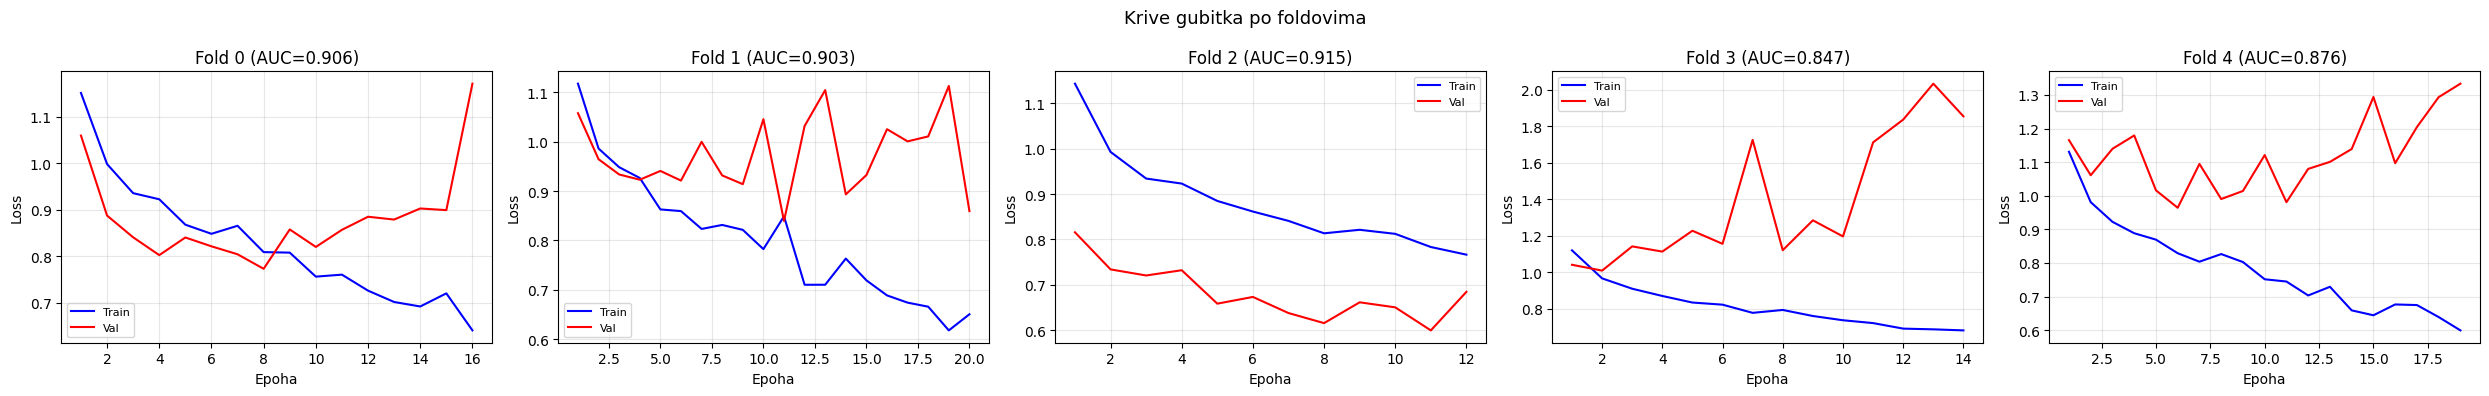

In [ ]:
fig = plot_all_folds_losses(resnet_results['per_fold_results'])
plt.show()

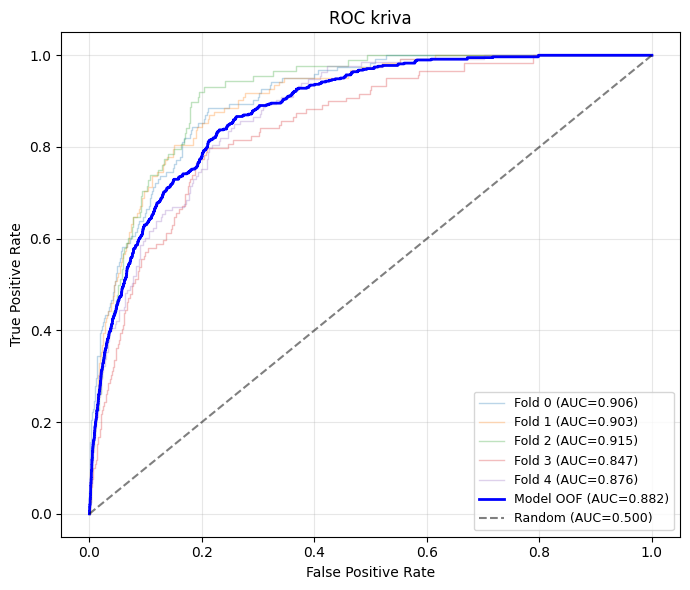

In [ ]:
fig = plot_roc_curve(
    resnet_results['oof_labels'],
    resnet_results['oof_probs'],
    fold_results=resnet_results['per_fold_results']
)
plt.show()

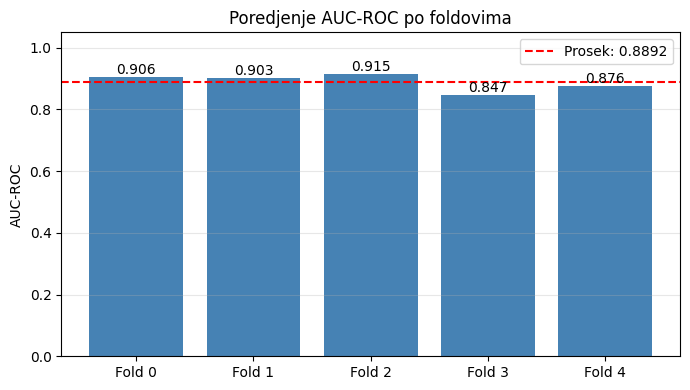


ResNet-50 Mean AUC: 0.8892 +/- 0.0249


In [ ]:
fig = plot_fold_comparison(resnet_results['per_fold_results'])
plt.show()

print(f"\nResNet-50 Mean AUC: {resnet_results['mean_auc']:.4f} +/- {resnet_results['std_auc']:.4f}")

### 6.4 Čuvanje ResNet-50 rezultata na Drive

In [ ]:
import pickle
resnet_save_path = os.path.join(RESULTS_DIR, 'resnet_results.pkl')
with open(resnet_save_path, 'wb') as f:
    pickle.dump(resnet_results, f)

print(f"ResNet-50 rezultati sacuvani u: {resnet_save_path}")

ResNet-50 rezultati sacuvani u: /content/drive/MyDrive/melanoma_results/resnet_results.pkl


ResNet-50 model je treniran. Sva 4 modela su sačuvana na Drive-u, pa prelazimo na poređenje.

---
## 7. Evaluacija - Poređenje sva 4 modela

Poredimo performanse sva 4 modela koristeci *out-of-fold* (OOF) predikcije iz cross-validacije.

Modeli:
1. Custom CNN - 3 konv. sloja, 128x128, treniran od nule
2. EfficientNet B0 - transfer learning, 224x224, 1280-dim backbone
3. DenseNet-121 - transfer learning, dense connections, 224x224, 1024-dim backbone
4. ResNet-50 - transfer learning, skip connections, 224x224, 2048-dim backbone

In [ ]:
import pickle

cnn_path = os.path.join(RESULTS_DIR, "cnn_results_new.pkl")
effnet_path = os.path.join(RESULTS_DIR, "effnet_results_new.pkl")
densenet_path = os.path.join(RESULTS_DIR, "densenet_results.pkl")

with open(cnn_path, 'rb') as f:
  cnn_results = pickle.load(f)

with open(effnet_path, 'rb') as f:
  effnet_results = pickle.load(f)

with open(densenet_path, 'rb') as f:
  densenet_results = pickle.load(f)

In [ ]:
from src.evaluation import compute_metrics, compute_metrics_at_best_threshold
from src.visualization import plot_roc_comparison, plot_confusion_matrix

all_results = {
    'Custom CNN': cnn_results,
    'EfficientNet B0': effnet_results,
    'DenseNet-121': densenet_results,
    'ResNet-50': resnet_results,
}

### 7.1 Poređenje ROC krivih

ROC kriva prikazuje odnos između *True Positive Rate (Recall)* i *False Positive Rate* za različite pragove odlučivanja. Veći AUC = bolji model.

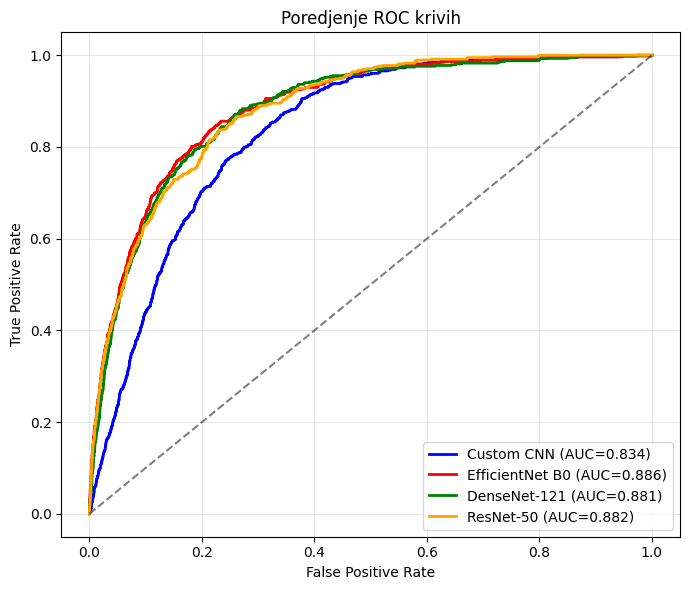


=== AUC-ROC poredjenje ===
Custom CNN           AUC: 0.8345 +/- 0.0173
EfficientNet B0      AUC: 0.8891 +/- 0.0209
DenseNet-121         AUC: 0.8882 +/- 0.0252
ResNet-50            AUC: 0.8892 +/- 0.0249


In [ ]:
fig = plot_roc_comparison(all_results)
plt.show()

print("\n=== AUC-ROC poredjenje ===")
for name, res in all_results.items():
    print(f"{name:<20} AUC: {res['mean_auc']:.4f} +/- {res['std_auc']:.4f}")

### 7.2 Detaljne metrike klasifikacije

Izračunavamo metrike za sva 4 modela koristeći:
1. Fiksni prag (0.5) - standardni prag
2. Optimalni prag (Youden's J) - maksimizuje TPR - FPR

In [ ]:
import pandas as pd

comparison_rows = []
optimal_thresholds = {}

for name, res in all_results.items():
    labels = res['oof_labels']
    probs = res['oof_probs']

    metrics_05 = compute_metrics(labels, probs, threshold=0.5)
    metrics_opt, opt_thresh = compute_metrics_at_best_threshold(labels, probs)
    optimal_thresholds[name] = opt_thresh

    comparison_rows.append({
        'Model': name,
        'AUC-ROC': metrics_05['auc_roc'],
        'PR-AUC': metrics_05['pr_auc'],
        'Opt. Threshold': opt_thresh,
        'Recall @0.5': metrics_05['recall'],
        'Recall @opt': metrics_opt['recall'],
        'Precision @opt': metrics_opt['precision'],
        'F1 @opt': metrics_opt['f1'],
        'Macro F1 @opt': metrics_opt['macro_f1'],
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.set_index('Model'))

print(f"\nNajbolji model po AUC-ROC: {comparison_df.loc[comparison_df['AUC-ROC'].idxmax(), 'Model']}")
print(f"Najbolji model po Macro F1: {comparison_df.loc[comparison_df['Macro F1 @opt'].idxmax(), 'Model']}")

,AUC-ROC,PR-AUC,Opt. Threshold,Recall @0.5,Recall @opt,Precision @opt,F1 @opt,Macro F1 @opt
Model,,,,,,,,
Custom CNN,0.834426,0.066508,0.404165,0.164384,0.852740,0.045310,0.086048,0.446283
EfficientNet B0,0.886044,0.167451,0.321609,0.607877,0.856164,0.061667,0.115048,0.490707
DenseNet-121,0.880878,0.135841,0.448907,0.844178,0.880137,0.055670,0.104716,0.474490
ResNet-50,0.881837,0.152878,0.413037,0.750000,0.837329,0.061087,0.113867,0.490938



Najbolji model po AUC-ROC: EfficientNet B0
Najbolji model po Macro F1: ResNet-50


U medicinskoj dijagnostici, Recall (senzitivnost) je kritična metrika jer minimizuje lažno negativne rezultate - propuštene melanome koji mogu biti fatalni.

Macro F1 uzima prosek F1-score-a za obe klase (Benign i Malignant), što je posebno korisno za nebalansiran dataset jer daje jednaku težinu manjinskoj klasi.

### 7.3 Matrice konfuzije

Prikazujemo matrice konfuzije za sva 4 modela sa optimalnim pragom.

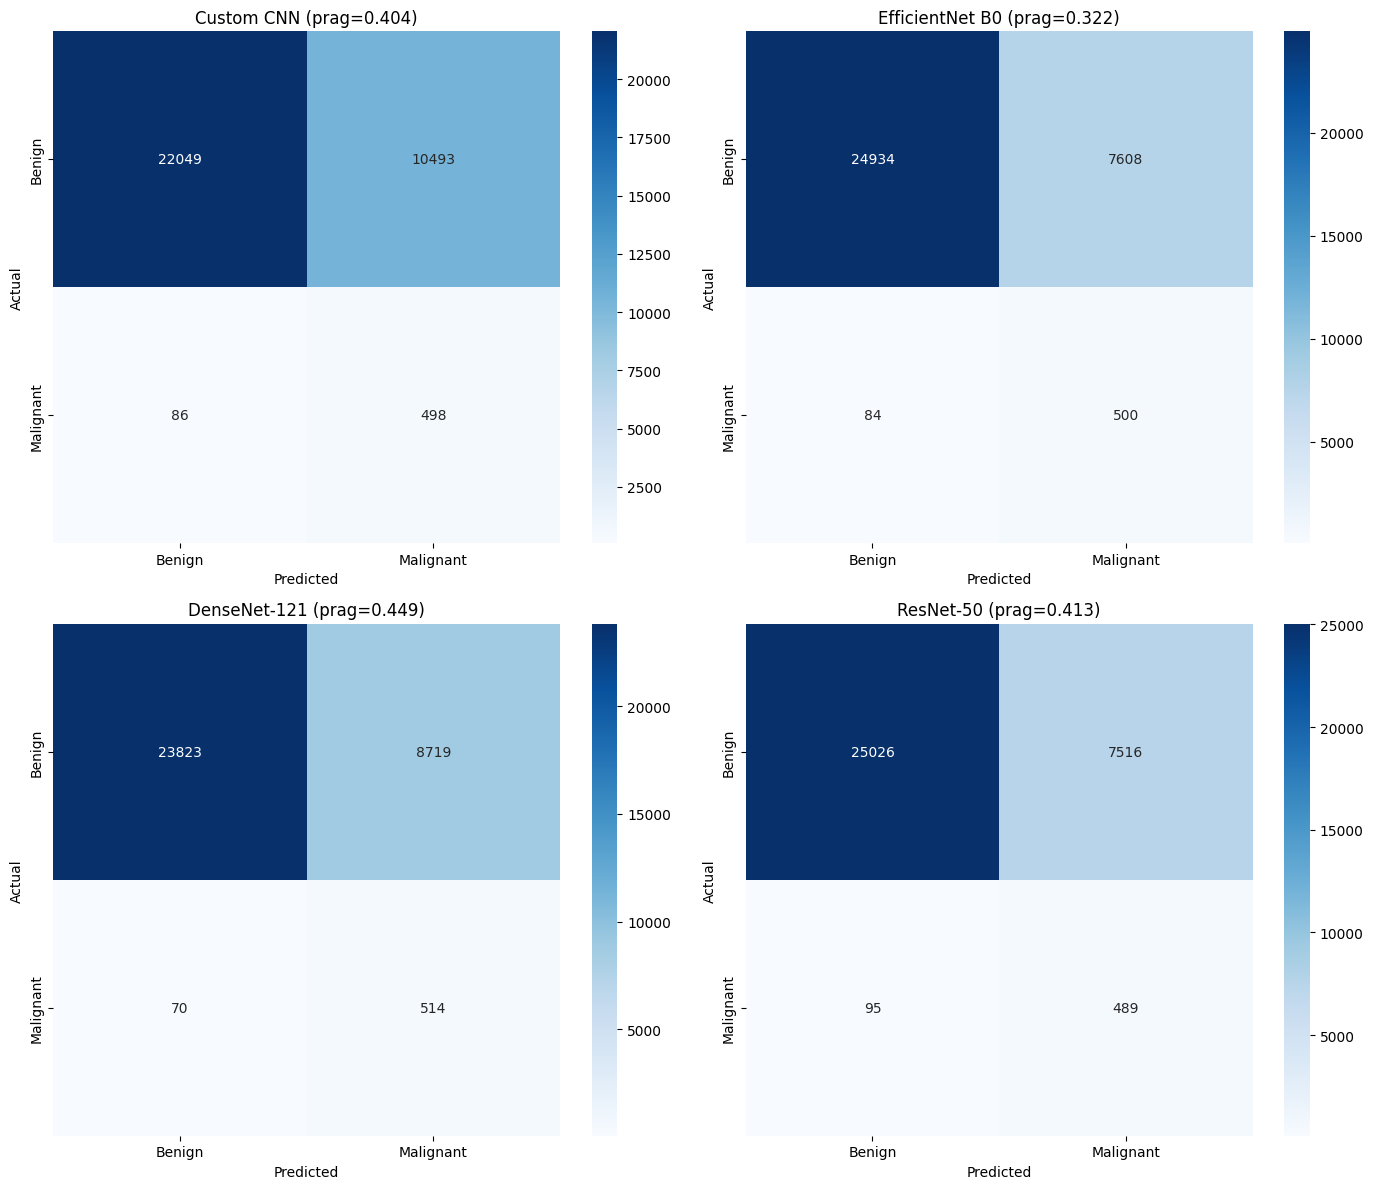

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, (name, res) in enumerate(all_results.items()):
    ax = axes[idx // 2][idx % 2]
    thresh = optimal_thresholds[name]
    preds = (res["oof_probs"] >= thresh).astype(int)
    cm = confusion_matrix(res["oof_labels"], preds)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])
    ax.set_title(f"{name} (prag={thresh:.3f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### 7.4 Classification Reports (optimalni prag)

In [ ]:
for name, res in all_results.items():
    thresh = optimal_thresholds[name]
    metrics = compute_metrics(res['oof_labels'], res['oof_probs'], threshold=thresh)
    print(f"\n{'='*50}")
    print(f"  {name} (prag={thresh:.3f})")
    print(f"{'='*50}")
    print(metrics['classification_report'])


  Custom CNN (prag=0.404)
              precision    recall  f1-score   support

      Benign       1.00      0.68      0.81     32542
   Malignant       0.05      0.85      0.09       584

    accuracy                           0.68     33126
   macro avg       0.52      0.77      0.45     33126
weighted avg       0.98      0.68      0.79     33126


  EfficientNet B0 (prag=0.322)
              precision    recall  f1-score   support

      Benign       1.00      0.77      0.87     32542
   Malignant       0.06      0.86      0.12       584

    accuracy                           0.77     33126
   macro avg       0.53      0.81      0.49     33126
weighted avg       0.98      0.77      0.85     33126


  DenseNet-121 (prag=0.449)
              precision    recall  f1-score   support

      Benign       1.00      0.73      0.84     32542
   Malignant       0.06      0.88      0.10       584

    accuracy                           0.73     33126
   macro avg       0.53      0.81      0

Poređenje sva 4 modela pokazuje relativne prednosti transfer learning-a nad custom CNN-om. EfficientNet, DenseNet i ResNet koriste ImageNet pretreniranje koje im daje znacajnu prednost u ekstrakciji vizuelnih obelezja.

---
## 8. Analiza grešaka modela

Analiziramo greške modela na dva nacina:
1. *Disagreement* analiza - gde se modeli ne slažu u predikcijama
2. *Error* analiza — prikaz lažno negativnih (propuštenih melanoma) i lažno pozitivnih primera

### 8.1 Model Disagreement analiza

Proveravamo koliko se cesto modeli ne slažu u predikcijama i ko je u pravu kad se ne slažu.

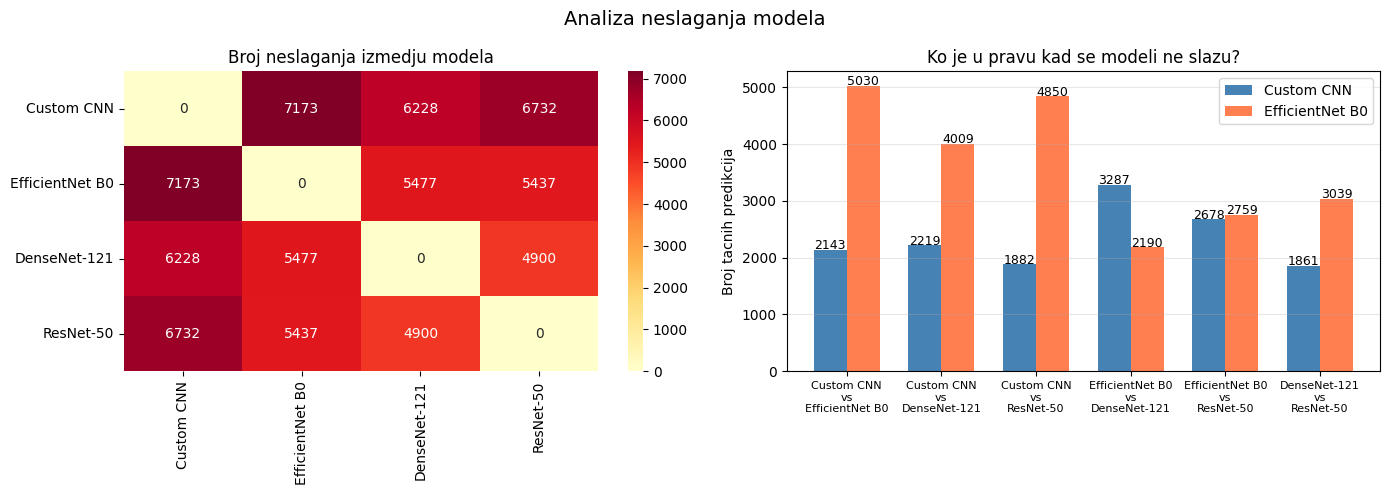

In [ ]:
from src.visualization import plot_model_disagreement

# plot_model_disagreement ocekuje dict sa oof_labels i oof_probs
fig = plot_model_disagreement(all_results, threshold=0.5)
plt.show()

Toplija boja u heatmapi = veci procenat neslaganja. Bar chart pokazuje koji model je tačniji kad se ne slaže sa drugim.

### 8.2 Error analiza - primeri gresaka

Prikazujemo najgore greske najboljeg modela:
- Lažno negativni (FN): Melanomi koje je model propustio - najopasnije greške u kliničkom kontekstu
- Lazno pozitivni (FP): Benigne lezije pogresno oznacene kao melanom

In [ ]:
from src.visualization import plot_error_analysis

# Odredimo najbolji model po AUC-ROC
best_model_name = max(all_results.keys(), key=lambda k: all_results[k]['mean_auc'])
best_results = all_results[best_model_name]
best_thresh = optimal_thresholds[best_model_name]

print(f"Analiza gresaka za: {best_model_name} (AUC={best_results['mean_auc']:.4f}, prag={best_thresh:.3f})")

# Kreiramo DataFrame sa predikcijama
error_df = df.copy()
error_df = error_df.reset_index(drop=True)
# OOF predikcije su vec poredane po fold-ovima — koristimo ih direktno
# Napomena: OOF labele i probs su sortirani po originalnom indeksu

fig = plot_error_analysis(
    error_df,
    best_results['oof_labels'],
    best_results['oof_probs'],
    img_dir=cfg.train_dir,
    model_name=best_model_name,
    n=6,  # Prikazujemo 6 najgorih gresaka
    threshold=best_thresh
)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

**Zaključak analize grešaka:**
- Lažno negativni (propušteni melanomi) su najkritičniji - ove lezije zahtevaju dalju inspekciju
- *Disagreement* između modela može se koristiti kao signal za nesigurne slučajeve
- *Ensemble* pristup (kombinacija vise modela) može smanjiti ove greške

---
## 9. Analiza pravičnosti (*Fairness*)

Analiziramo pravičnost modela koristeći *Equalized Odds* metriku.

*Equalized Odds* zahteva da model ima jednake:
- TPR (*True Positive Rate / Recall*) - sposobnost detekcije melanoma
- FPR (*False Positive Rat*e) - stopa lažnih alarma

za sve demografske grupe (pol, starost, tip kože).

In [ ]:
from src.fairness import full_fairness_report
from src.visualization import plot_fairness_bars

# Koristimo najbolji model
best_model_name = max(all_results.keys(), key=lambda k: all_results[k]['mean_auc'])
best_results = all_results[best_model_name]
best_threshold = optimal_thresholds[best_model_name]

print(f"Fairness analiza za: {best_model_name}")
print(f"AUC-ROC: {best_results['mean_auc']:.4f}, Prag: {best_threshold:.3f}")

oof_labels = best_results['oof_labels']
oof_probs = best_results['oof_probs']
oof_df = df.reset_index(drop=True)

Fairness analiza za: ResNet-50
AUC-ROC: 0.8892, Prag: 0.413


In [ ]:
report = full_fairness_report(oof_df, oof_labels, oof_probs, threshold=best_threshold)

/content/neuronske-2/src/fairness.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in temp.groupby(group_column):


### 9.1 Pravičnost po polu

Analiziramo da li model jednako dobro prepoznaje melanom kod muških i ženskih pacijenata.

Equalized Odds po polu:


,group,tpr,fpr,n_samples,n_positive,n_negative
0,female,0.836177,0.230431,15981,293,15688
1,male,0.837370,0.231553,17080,289,16791
2,unknown,1.000000,0.206349,65,2,63



TPR disparitet: 0.16382252559726962
FPR disparitet: 0.025203411124440245


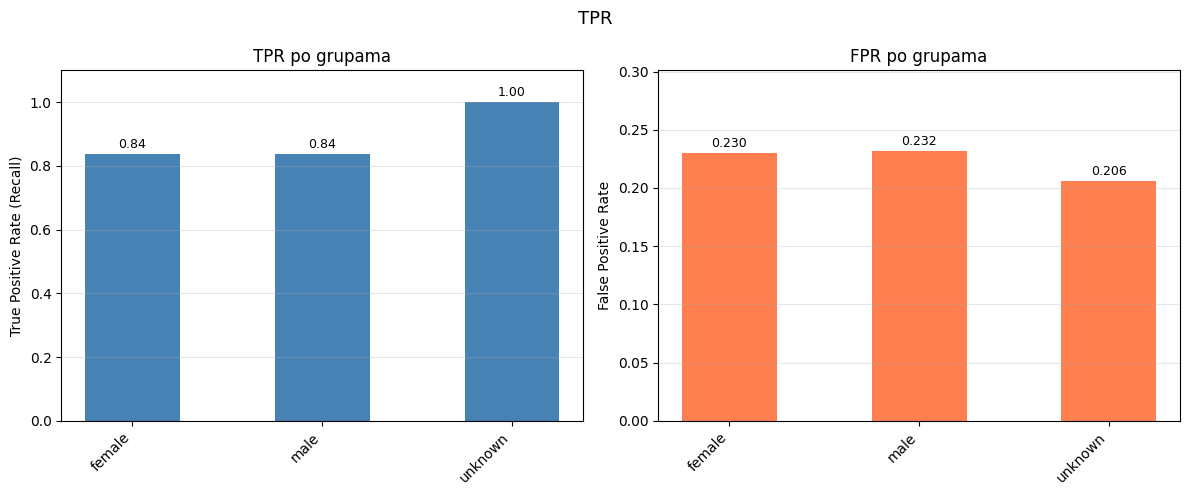

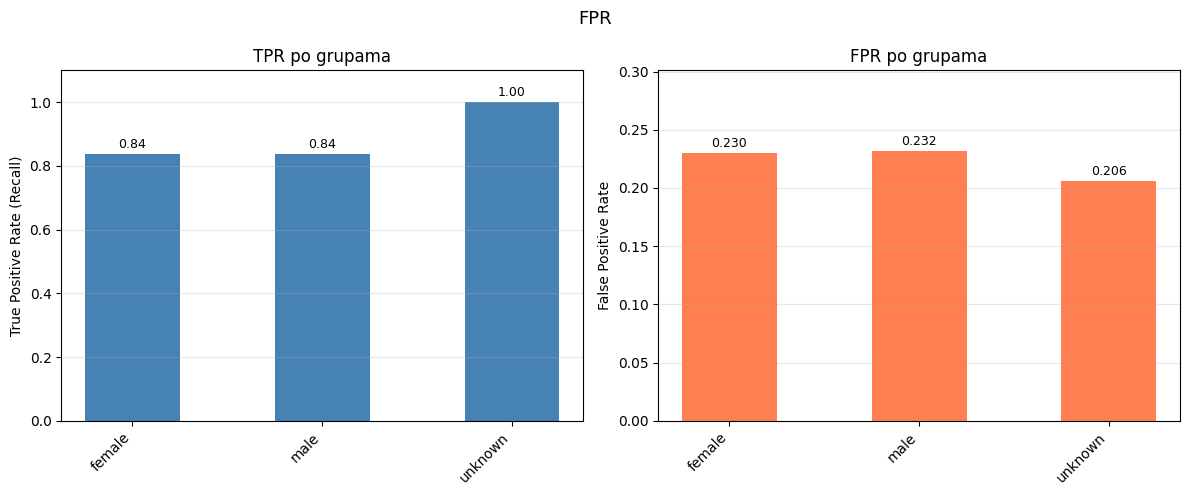

In [ ]:
if 'sex' in report:
    print("Equalized Odds po polu:")
    display(report['sex'])

    tpr_disp = report['sex'].attrs.get('tpr_disparity', 'N/A')
    fpr_disp = report['sex'].attrs.get('fpr_disparity', 'N/A')
    print(f"\nTPR disparitet: {tpr_disp}")
    print(f"FPR disparitet: {fpr_disp}")

    # fig = plot_fairness_bars(report['sex'], 'sex', 'TPR')
    # plt.show()

    # Umesto 'sex', prosledi 'group' jer se tako zove kolona u tvom report-u
    fig = plot_fairness_bars(report['sex'], 'group', 'TPR')
    plt.show()
    fig = plot_fairness_bars(report['sex'], 'group', 'FPR')
    plt.show()
else:
    print("Kolona 'sex' nije pronadjena u podacima.")

Idealno, TPR i FPR bi trebalo da budu jednaki za obe grupe. Veliki disparitet ukazuje na to da model bolje/gore detektuje melanom za jednu grupu.

### 9.2 Pravičnost po starosnoj grupi

Melanom je češći kod starijih pacijenata. Proveravamo da li model jednako dobro funkcioniše za sve starosne grupe.

Equalized Odds po starosnoj grupi:


,group,tpr,fpr,n_samples,n_positive,n_negative
0,<30,0.702128,0.230569,2350,47,2303
1,30-44,0.858065,0.229575,8784,155,8629
2,45-59,0.850467,0.233124,12628,214,12414
3,60-74,0.888060,0.228391,7735,134,7601
4,75+,0.647059,0.234483,1629,34,1595



TPR disparitet: 0.24100087796312553
FPR disparitet: 0.006091757436634926


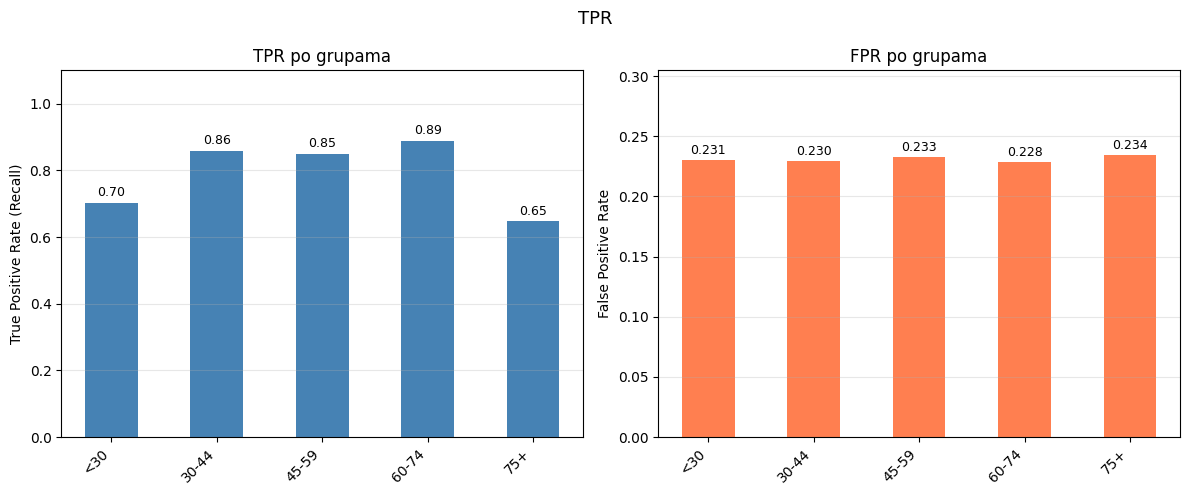

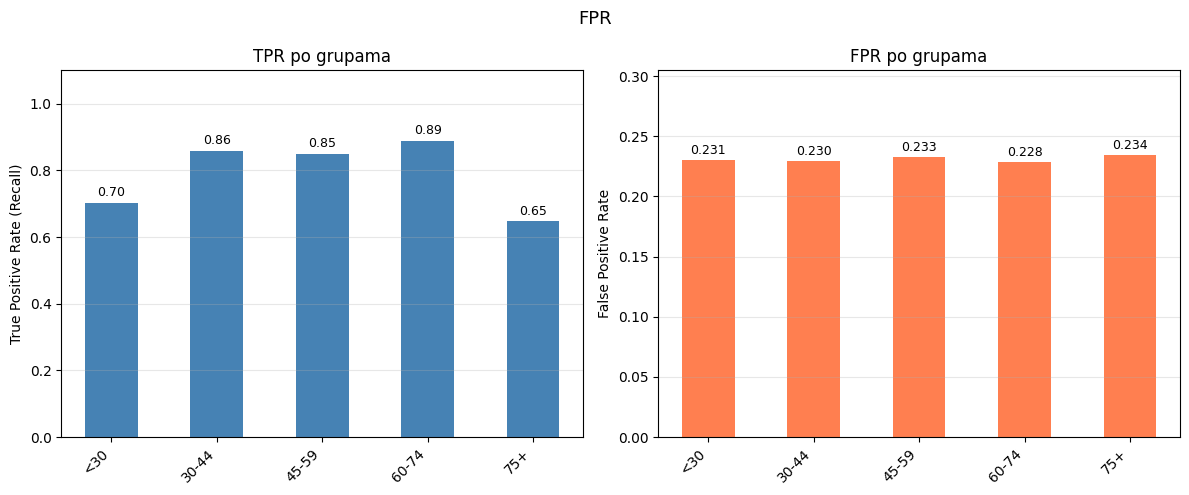

In [ ]:
if 'age_group' in report:
    print("Equalized Odds po starosnoj grupi:")
    display(report['age_group'])

    tpr_disp = report['age_group'].attrs.get('tpr_disparity', 'N/A')
    fpr_disp = report['age_group'].attrs.get('fpr_disparity', 'N/A')
    print(f"\nTPR disparitet: {tpr_disp}")
    print(f"FPR disparitet: {fpr_disp}")

    fig = plot_fairness_bars(report['age_group'], 'group', 'TPR')
    plt.show()
    fig = plot_fairness_bars(report['age_group'], 'group', 'FPR')
    plt.show()
else:
    print("Kolona 'age_group' nije pronadjena.")

### 9.3 Sumarni pregled dispariteta

In [ ]:
print(f"=== Sumarni pregled dispariteta za {best_model_name} ===")
print(f"{'Grupa':<20} {'TPR disparitet':>15} {'FPR disparitet':>15}")
print("-" * 50)
for group_name, group_df in report.items():
    tpr_d = group_df.attrs.get('tpr_disparity', 'N/A')
    fpr_d = group_df.attrs.get('fpr_disparity', 'N/A')
    if isinstance(tpr_d, float):
        print(f"{group_name:<20} {tpr_d:>15.4f} {fpr_d:>15.4f}")
    else:
        print(f"{group_name:<20} {tpr_d:>15} {fpr_d:>15}")

=== Sumarni pregled dispariteta za ResNet-50 ===
Grupa                 TPR disparitet  FPR disparitet
--------------------------------------------------
sex                           0.1638          0.0252
age_group                     0.2410          0.0061


Zaključak *fairness* analize:

- Disparitet u TPR ukazuje na razliku u sposobnosti detekcije melanoma izmedju grupa
- Disparitet u FPR ukazuje na razliku u stopi lažnih pozitiva
- Manji disparitet = pravičniji model
- Za kliničku primenu, razlike u TPR su kritične jer znace da se melanom gore detektuje za neke grupe

---
## 10. Rezime rezultata

Kompletni pipeline za klasifikaciju melanoma je zavrsen sa 4 modela.

In [ ]:
print("=" * 70)
print("  REZIME REZULTATA - 4 MODELA")
print("=" * 70)
print(f"\nDataset: {len(df)} slika, {df['patient_id'].nunique()} pacijenata")
print(f"Klasa distribucija: {(df['target']==0).sum()} benign ({(df['target']==0).mean()*100:.1f}%), "
      f"{(df['target']==1).sum()} malign ({(df['target']==1).mean()*100:.1f}%)")
print(f"\nEvaluacija: {cfg.num_folds}-fold StratifiedGroupKFold po patient_id")
print(f"Loss: Focal Loss (alpha=0.25, gamma=2.0)")

print(f"\n{'Model':<20} {'Mean AUC':>12} {'Std AUC':>10} {'PR-AUC':>10} {'Macro F1':>10}")
print("-" * 62)
for name, res in all_results.items():
    metrics = compute_metrics(res['oof_labels'], res['oof_probs'], threshold=optimal_thresholds[name])
    print(f"{name:<20} {res['mean_auc']:>12.4f} {res['std_auc']:>10.4f} {metrics['pr_auc']:>10.4f} {metrics['macro_f1']:>10.4f}")

best_name = max(all_results.keys(), key=lambda k: all_results[k]['mean_auc'])
print(f"\nNajbolji model: {best_name} (AUC={all_results[best_name]['mean_auc']:.4f})")

print(f"\nSacuvani fajlovi na Drive-u:")
for fname in ['cnn_results.pkl', 'effnet_results_new.pkl', 'densenet_results.pkl', 'resnet_results.pkl']:
    fpath = os.path.join(RESULTS_DIR, fname)
    status = 'postoji' if os.path.exists(fpath) else 'NEDOSTAJE'
    print(f"  {fpath} [{status}]")

  REZIME REZULTATA - 4 MODELA

Dataset: 33126 slika, 2056 pacijenata
Klasa distribucija: 32542 benign (98.2%), 584 malign (1.8%)

Evaluacija: 5-fold StratifiedGroupKFold po patient_id
Loss: Focal Loss (alpha=0.25, gamma=2.0)

Model                    Mean AUC    Std AUC     PR-AUC   Macro F1
--------------------------------------------------------------
Custom CNN                 0.8345     0.0173     0.0665     0.4463
EfficientNet B0            0.8891     0.0209     0.1675     0.4907
DenseNet-121               0.8882     0.0252     0.1358     0.4745
ResNet-50                  0.8892     0.0249     0.1529     0.4909

Najbolji model: ResNet-50 (AUC=0.8892)

Sacuvani fajlovi na Drive-u:
  /content/drive/MyDrive/melanoma_results/cnn_results.pkl [postoji]
  /content/drive/MyDrive/melanoma_results/effnet_results_new.pkl [postoji]
  /content/drive/MyDrive/melanoma_results/densenet_results.pkl [postoji]
  /content/drive/MyDrive/melanoma_results/resnet_results.pkl [postoji]


Svi rezultati su sacuvani na Google Drive-u u `melanoma_results/` folderu.